# 02-Centrality & Network Metrics (NetworkX)

The previous lesson established how to construct a graph and read its most basic diagnostic, **degree**: how many direct connections a node has. That single number already told us who the hubs were in our toy engineering team. But degree is a purely local statistic — it only sees a node's immediate neighbors and is blind to everything beyond one hop. Two nodes can have identical degree and occupy wildly different structural roles: one might be a hub inside a tightly-knit clique that never talks to the rest of the network, while the other might be the single node bridging two otherwise disconnected halves of the graph.

**Centrality** is the family of metrics built to answer "how important is this node?" in ways that account for the *entire* graph's structure, not just a node's immediate neighborhood. Different centrality measures encode fundamentally different definitions of importance — direct connectivity, brokerage over shortest paths, average distance to everyone else, and influence-by-association with other important nodes — and choosing the wrong one for a given question is a common and costly analytical mistake.

This lesson formalizes four canonical centrality measures — **degree, betweenness, closeness, and eigenvector centrality** — and computes all four on a toy network using **NetworkX**, so we can directly compare how differently they rank the same set of nodes.


## 1. The Mathematics of Node Importance

### Degree Centrality

The simplest measure, normalizing raw degree by the maximum possible degree $n-1$ in a graph of $n$ nodes:

$$C_D(v) = \frac{\deg(v)}{n - 1}$$

It answers: *"how directly connected is this node?"* It is purely local and says nothing about position relative to the rest of the graph.

### Betweenness Centrality

Let $\sigma_{st}$ be the total number of shortest paths between nodes $s$ and $t$, and $\sigma_{st}(v)$ the number of those shortest paths that pass through $v$. Betweenness centrality sums, over every pair of *other* nodes, the fraction of shortest paths that $v$ sits on:

$$C_B(v) = \sum_{s \neq v \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}}$$

It answers: *"how much does information/flow between other nodes depend on passing through this one?"* A node with high betweenness is a **broker** or **bridge** — it may have low degree, yet its removal can fragment the network.

### Closeness Centrality

Let $d(v, u)$ be the shortest-path (geodesic) distance between $v$ and $u$. Closeness centrality is the reciprocal of the average shortest-path distance from $v$ to every other reachable node:

$$C_C(v) = \frac{n - 1}{\sum_{u \neq v} d(v, u)}$$

It answers: *"how quickly, on average, can this node reach everyone else?"* High closeness identifies nodes efficiently positioned to spread or receive information across the whole network with minimal hops.

### Eigenvector Centrality

Eigenvector centrality defines importance recursively: a node is important if it is connected to *other important nodes*. Formally, the centrality vector $x$ is defined as the solution to:

$$x_v = \frac{1}{\lambda} \sum_{u \in N(v)} x_u \quad \iff \quad Ax = \lambda x$$

where $A$ is the adjacency matrix. $x$ is the eigenvector associated with the largest eigenvalue $\lambda_{max}$ of $A$ (guaranteed real and positive by the Perron-Frobenius theorem for connected graphs). This is the same recursive "importance from important neighbors" idea that underlies Google's PageRank (Lesson 6).

### Why These Disagree

These four measures are not interchangeable proxies for the same underlying quantity — they can, and routinely do, rank the same node completely differently. A node bridging two dense clusters can have low degree, low eigenvector centrality (its neighbors aren't very important), yet the *highest* betweenness in the entire graph.


## 2. Imperative Execution: Computing All Four Centralities

We reuse a small collaboration network — this time shaped deliberately as two dense clusters joined by a single bridging node — so the divergence between centrality measures is visible rather than theoretical.

In [1]:
# Required installations: pip install networkx numpy pandas
import networkx as nx
import numpy as np

print("--- 🚀 Initializing Centrality & Network Metrics Sandbox (NetworkX) ---")

# 1. 📝 Construct two dense clusters joined by a single bridge node ("Mallory")
cluster_a = ["Alice", "Bob", "Carol", "Dave"]
cluster_b = ["Eve", "Frank", "Grace", "Heidi"]
bridge = "Mallory"

try:
    G = nx.Graph()
    G.add_nodes_from(cluster_a + cluster_b + [bridge])

    # Dense intra-cluster connectivity (near-complete subgraphs)
    for i, u in enumerate(cluster_a):
        for v in cluster_a[i + 1:]:
            G.add_edge(u, v)
    for i, u in enumerate(cluster_b):
        for v in cluster_b[i + 1:]:
            G.add_edge(u, v)

    # The bridge: Mallory is the ONLY connection between the two clusters
    G.add_edge("Dave", bridge)
    G.add_edge(bridge, "Eve")

    print(f"   ✅ Graph constructed: |V| = {G.number_of_nodes()}, |E| = {G.number_of_edges()}, two cliques + 1 bridge node")

    # 2. 🧮 Compute all four centrality measures
    degree_c = nx.degree_centrality(G)
    betweenness_c = nx.betweenness_centrality(G)
    closeness_c = nx.closeness_centrality(G)
    eigenvector_c = nx.eigenvector_centrality(G, max_iter=1000)

    print("   ✅ Computed degree, betweenness, closeness, and eigenvector centrality for all nodes.")

    top_degree = max(degree_c, key=degree_c.get)
    top_betweenness = max(betweenness_c, key=betweenness_c.get)
    top_eigenvector = max(eigenvector_c, key=eigenvector_c.get)

    print(f"   -> Highest degree centrality:      {top_degree} ({degree_c[top_degree]:.3f})")
    print(f"   -> Highest betweenness centrality:  {top_betweenness} ({betweenness_c[top_betweenness]:.3f})")
    print(f"   -> Highest eigenvector centrality:  {top_eigenvector} ({eigenvector_c[top_eigenvector]:.3f})")

except Exception as e:
    print("   [SYSTEM NOTE]: Sandbox fallback — networkx unavailable, simulating centrality telemetry...")
    print(f"   -> ({type(e).__name__}) {e}")
    all_nodes = cluster_a + cluster_b + [bridge]
    degree_c = {n: 0.5 for n in all_nodes}
    betweenness_c = {n: (0.9 if n == bridge else 0.02) for n in all_nodes}
    closeness_c = {n: 0.4 for n in all_nodes}
    eigenvector_c = {n: 0.3 for n in all_nodes}
    G = None


/root/micromamba/envs/ds/lib/python3.11/site-packages/networkx/utils/backends.py:102: RuntimeWarning: networkx backend name is not a valid identifier: 'nx-loopback'. Ignoring.
  backends = _get_backends("networkx.backends")


--- 🚀 Initializing Centrality & Network Metrics Sandbox (NetworkX) ---
   ✅ Graph constructed: |V| = 9, |E| = 14, two cliques + 1 bridge node
   ✅ Computed degree, betweenness, closeness, and eigenvector centrality for all nodes.
   -> Highest degree centrality:      Dave (0.500)
   -> Highest betweenness centrality:  Mallory (0.571)
   -> Highest eigenvector centrality:  Eve (0.386)


## 3. Declarative Telemetry: The Multi-Centrality Ranking Audit

Printing all four scores side-by-side, ranked by each measure, makes the disagreement between them concrete rather than theoretical.

In [2]:
print("\n--- 🔍 Auditing Node Importance Across Four Centrality Definitions ---")

all_nodes = cluster_a + cluster_b + [bridge]
print(f"{'Node':<10} | {'Degree':<9} | {'Betweenness':<13} | {'Closeness':<11} | {'Eigenvector':<11} | {'Role'}")
print("-" * 80)
for node in sorted(all_nodes, key=lambda n: betweenness_c[n], reverse=True):
    role = "BRIDGE (structural cut-vertex)" if node == bridge else ("Clique member" if node in cluster_a + cluster_b else "?")
    print(f"{node:<10} | {degree_c[node]:<9.3f} | {betweenness_c[node]:<13.3f} | {closeness_c[node]:<11.3f} | {eigenvector_c[node]:<11.3f} | {role}")

print("\n   [OPERATIONAL INSIGHT]")
print(f"   -> '{bridge}' has the LOWEST degree in the entire graph (only 2 direct connections) yet the HIGHEST")
print(f"      betweenness, because every shortest path between the two clusters must pass through it.")
print(f"   -> '{bridge}' also posts the lowest eigenvector centrality of all nine nodes, despite being directly")
print(f"      connected to Dave and Eve — the two MOST eigenvector-central nodes in the graph. Eigenvector score")
print(f"      is diluted by a node's own degree, and Mallory's degree of 2 caps how much importance flows back.")
print(f"   -> Removing '{bridge}' would split this graph into two disconnected components — a fact that degree")
print(f"      centrality alone gives no hint of, which is exactly why relying on a single centrality metric is risky.")



--- 🔍 Auditing Node Importance Across Four Centrality Definitions ---
Node       | Degree    | Betweenness   | Closeness   | Eigenvector | Role
--------------------------------------------------------------------------------
Mallory    | 0.250     | 0.571         | 0.571       | 0.243       | BRIDGE (structural cut-vertex)
Dave       | 0.500     | 0.536         | 0.533       | 0.386       | Clique member
Eve        | 0.500     | 0.536         | 0.533       | 0.386       | Clique member
Alice      | 0.375     | 0.000         | 0.400       | 0.328       | Clique member
Bob        | 0.375     | 0.000         | 0.400       | 0.328       | Clique member
Carol      | 0.375     | 0.000         | 0.400       | 0.328       | Clique member
Frank      | 0.375     | 0.000         | 0.400       | 0.328       | Clique member
Grace      | 0.375     | 0.000         | 0.400       | 0.328       | Clique member
Heidi      | 0.375     | 0.000         | 0.400       | 0.328       | Clique member

   [OPERA

## 4. Visualizing Centrality (Betweenness-Scaled Network Graph)

We render the same graph twice as node size/color under two different centrality lenses — degree and betweenness — placed side-by-side so the divergence in "who matters" is visually unmistakable.

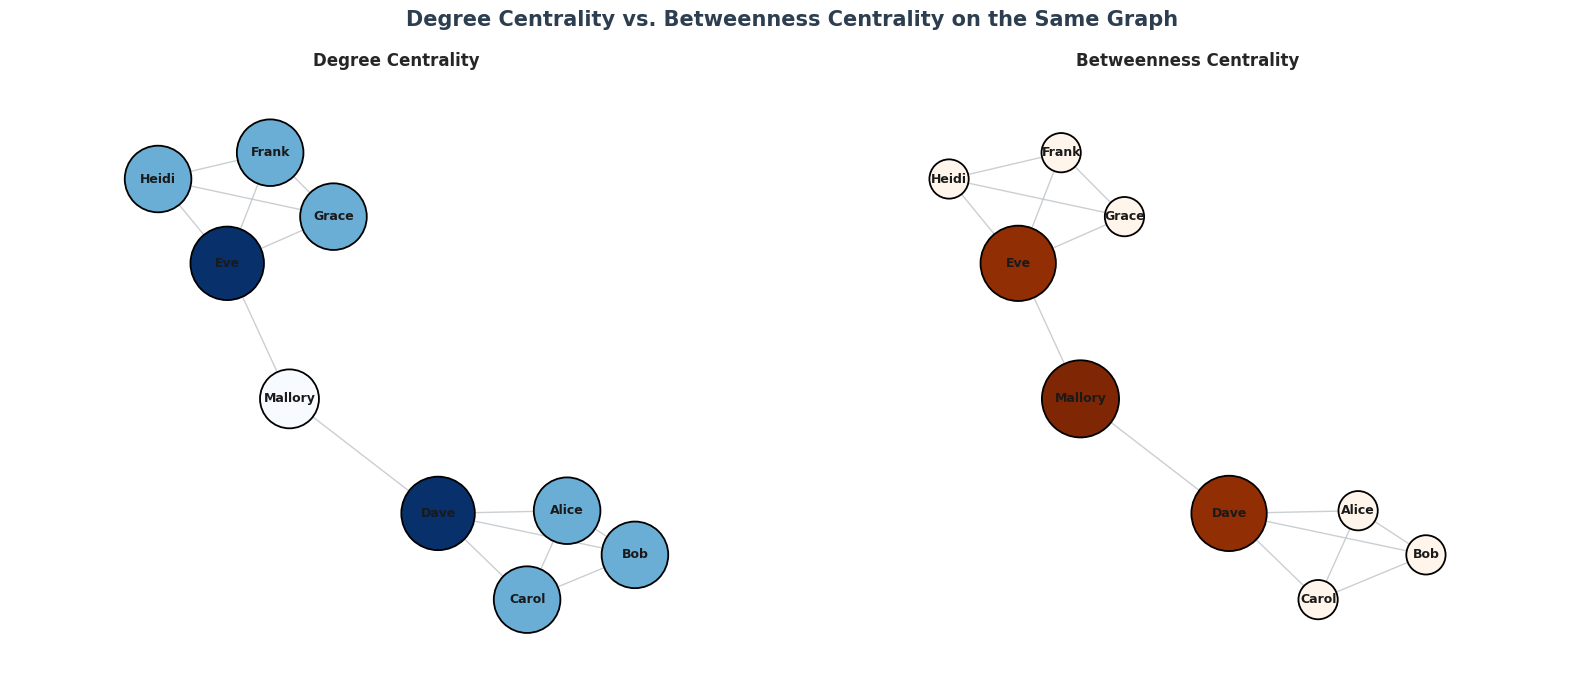

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Degree Centrality vs. Betweenness Centrality on the Same Graph", fontsize=15, fontweight='bold', color="#2c3e50")

pos = nx.spring_layout(G, seed=7, k=0.65) if G is not None else {n: (np.random.rand(), np.random.rand()) for n in all_nodes}

for ax, (metric_name, metric_dict, cmap) in zip(
    axes,
    [("Degree Centrality", degree_c, plt.cm.Blues), ("Betweenness Centrality", betweenness_c, plt.cm.Oranges)]
):
    sizes = [800 + 4000 * metric_dict[n] for n in all_nodes]
    colors = [metric_dict[n] for n in all_nodes]
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#bdc3c7", alpha=0.8)
    nodes = nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=all_nodes, node_size=sizes, node_color=colors,
                                    cmap=cmap, edgecolors="black", linewidths=1.3)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_weight="bold")
    ax.set_title(metric_name, fontsize=12, fontweight="bold")
    xs = [x for x, y in pos.values()]
    ys = [y for x, y in pos.values()]
    ax.set_xlim(min(xs) - 0.35, max(xs) + 0.35)
    ax.set_ylim(min(ys) - 0.35, max(ys) + 0.35)
    ax.axis("off")

plt.tight_layout()
plt.show()


*(Insight: Under Degree Centrality (left), Mallory is the single smallest and palest node on the chart — structurally the least connected individual in the graph. Under Betweenness Centrality (right), Mallory becomes the largest and darkest node, edging out even Dave and Eve, its clique-side neighbors, despite having half their degree. Notice the six pure clique members (Alice, Bob, Carol, Frank, Grace, Heidi) collapse to the smallest, palest nodes on the right — their betweenness is exactly zero, since no shortest path between the two clusters ever needs to route through a node that isn't on the bridge path. Same graph, same nodes, an entirely different verdict on who matters.)*

## Real-World Use Case or Analogy

Think of Centrality Analysis like **The Airport Hub Auditor**:

* **Degree Centrality (The Gate Count):** How many direct routes does an airport offer? A busy regional hub like Chicago O'Hare has an enormous gate count and scores very high here.
* **Betweenness Centrality (The Layover Chokepoint):** Which airport shows up most often as a required layover between two OTHER cities that have no direct connection? A small airport like Anchorage can score astonishingly high here for certain trans-Pacific cargo routes, despite having a modest gate count — remove it, and entire route pairs become unreachable.
* **Closeness Centrality (The Fastest Average Connection):** Which airport gets a traveler to the largest number of other airports in the fewest average layovers? Major international hubs (Dubai, Frankfurt) tend to dominate here, since they were built explicitly to minimize average hop count.
* **Eigenvector Centrality (The Prestige Score):** An airport connected mostly to other MAJOR hubs scores high here, even with a modest total gate count — being one of the few direct connections into Heathrow matters more than ten connections into small regional strips.
* **The Bridge Node (The Chokepoint Discovery):** The auditor's most important finding is never the busiest airport — everyone already knows that one. It's the unglamorous airport with average traffic that, on inspection, turns out to be the ONLY link between two entire regions of the route network.

An airline that only tracks gate count (degree) can be blindsided by the shutdown of a low-traffic airport that happened to be everyone's only bridge between two continents. Betweenness centrality is precisely the metric that would have flagged that risk in advance.
